---
tags: [tutorial]
---

# Controlling Gates and Sub-Kernels with `qmc.control`

*(intro paragraph — to be written)*

In [1]:
# Install the latest Qamomile from pip.
# !pip install qamomile

In [2]:
import math

import qamomile.circuit as qmc
from qamomile.circuit.transpiler.errors import (
    QubitConsumedError,
    UnreturnedBorrowError,
)
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## 1. The minimal example: controlled-RX

The smallest useful application of `qmc.control` is wrapping a
single built-in rotation. `qmc.rx(q, angle)` is a one-qubit
gate; passing it to `qmc.control` produces a two-qubit
controlled-RX.

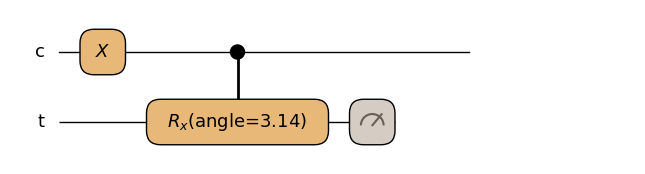

In [3]:
@qmc.qkernel
def crx_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    # Drive the control to |1> so the controlled rotation fires.
    c = qmc.x(c)
    crx = qmc.control(qmc.rx)
    c, t = crx(c, t, angle=math.pi)
    return qmc.measure(t)


crx_demo.draw()

Three things to notice at the call site:

- `qmc.control(qmc.rx)` is evaluated at *decoration time*. The
  returned `ControlledGate` (here bound to `crx`) is a reusable
  value; you can stash it in a variable and call it multiple
  times.
- When you call `crx(c, t, angle=...)`, the control qubits come
  first as positional arguments, then the targets, then any
  classical keyword arguments. The order mirrors the wrapped
  `qmc.rx(q, angle)` signature with one extra control prefixed.
- The keyword name for the classical parameter is whatever the
  wrapped function uses (`angle` for `qmc.rx`, `theta` for
  `qmc.p`, etc.) — `qmc.control` does not rename it.

## 2. Two modes at a glance

`qmc.control` has two modes. Which one you are in is decided
entirely by the type you pass for `num_controls`: a Python
`int` puts you in *concrete* mode, a `qmc.UInt` handle (or any
`UInt` expression like `n - 1`) puts you in *symbolic* mode.
Everything else about the call follows from that choice.

| Aspect | Concrete | Symbolic |
| --- | --- | --- |
| `num_controls=` | Python `int` (default `1`) | `qmc.UInt` handle, or any `UInt` expression |
| Control argument(s) | one or more positional args (`Qubit`, `VectorView`, or `Vector[Qubit]`) whose qubit counts sum to `num_controls` | exactly one `Vector[Qubit]` or `VectorView` *pool* |
| `controlled_indices=` | not accepted | optional — picks which slots of the pool are active |
| Control count resolved at | decoration time | transpile time (from `bindings`) |

A short decision rule: reach for *concrete* mode when the
control count is a literal you know while writing the qkernel
and you want to name each control qubit individually. Reach for
*symbolic* mode when the count is a kernel parameter (or an
expression over one — `num_controls=n - 1` is the textbook
multi-controlled form).

Most of `qmc.control`'s features (`power=`, default values,
classical-kwarg reordering, sub-kernels that take
`Vector[Qubit]`, ...) behave identically in both modes; Section
3 collects those. The handful of features that are mode-specific
are split between Section 4 (concrete only) and Section 5
(symbolic only).

## 3. Patterns that work in BOTH modes

Everything in this section is mode-agnostic. Each subsection
shows the feature in concrete mode (because the code is shorter
without a `UInt` kernel parameter in the picture), but the same
call site works in symbolic mode if you replace
`num_controls=<int>` with `num_controls=<UInt expression>`.

### 3.1 Wrapping any callable

`qmc.control` accepts either a built-in gate function (`qmc.rx`,
`qmc.h`, `qmc.p`, ...) or any user-defined `@qmc.qkernel`. The
wrapper does not care which: it looks at the wrapped callable's
signature, extracts the quantum operands and the classical
parameters, and emits a controlled-U around the rest. In the
example below, `ch` wraps a single primitive and `cg` wraps a
user-defined kernel body with two gates inside.

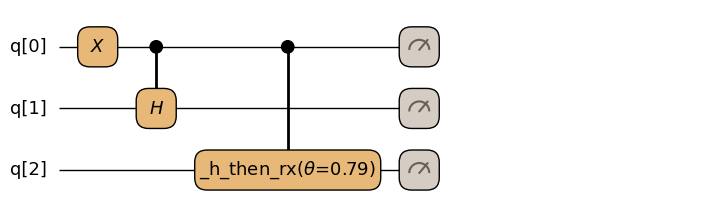

In [4]:
@qmc.qkernel
def _h_then_rx(q: qmc.Qubit, theta: qmc.Float) -> qmc.Qubit:
    q = qmc.h(q)
    q = qmc.rx(q, theta)
    return q


@qmc.qkernel
def wrap_any_callable_demo() -> qmc.Vector[qmc.Bit]:
    # q[0] is the shared control; q[1] / q[2] are the two targets.
    q = qmc.qubit_array(3, "q")
    q[0] = qmc.x(q[0])
    ch = qmc.control(qmc.h)  # built-in gate function
    q[0], q[1] = ch(q[0], q[1])
    cg = qmc.control(_h_then_rx)  # user @qmc.qkernel
    q[0], q[2] = cg(q[0], q[2], theta=math.pi / 4)
    return qmc.measure(q)


wrap_any_callable_demo.draw()

### 3.2 Sub-kernel taking `Vector[Qubit]`

A wrapped kernel may take a `Vector[Qubit]` argument. The caller
passes a `Vector` or a `VectorView` of the matching length, and
the controlled-U emit pass expands the body per-element so each
inner gate becomes a controlled gate on the right physical
qubit. This is how you control a register-wide operation without
spelling out one operand per qubit at the call site.

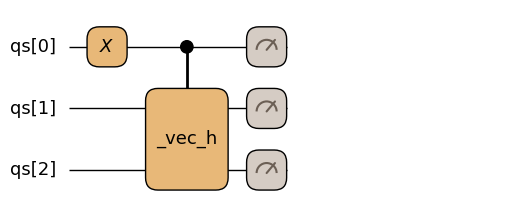

In [5]:
@qmc.qkernel
def _vec_h(qs: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    qs[0] = qmc.h(qs[0])
    qs[1] = qmc.h(qs[1])
    return qs


@qmc.qkernel
def vec_target_demo() -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(3, "qs")
    qs[0] = qmc.x(qs[0])
    cg = qmc.control(_vec_h, num_controls=1)
    qs[0], qs[1:3] = cg(qs[0], qs[1:3])
    return qmc.measure(qs)


vec_target_demo.draw()

### 3.3 Default values from the wrapped kernel's signature

When the wrapped `@qmc.qkernel` declares a Python default for a
classical parameter, callers may omit that keyword. The wrapper
fills the missing value in via `inspect.Signature.bind +
apply_defaults`, so the default reaches the controlled-U just
like a normal direct call. (Only `@qmc.qkernel`-wrapped
callables can carry defaults — see Section 6.9 for what happens
if you try to do the same with a plain Python function.)

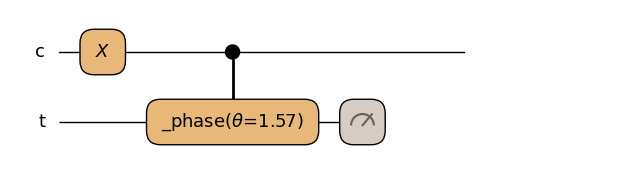

In [6]:
@qmc.qkernel
def _phase(q: qmc.Qubit, theta: qmc.Float = math.pi / 2) -> qmc.Qubit:
    return qmc.rx(q, theta)


@qmc.qkernel
def default_arg_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_phase)
    c, t = cg(c, t)  # theta defaults to math.pi / 2
    return qmc.measure(t)


default_arg_demo.draw()

### 3.4 Classical keyword arguments in any order

Classical kwargs at the call site are matched by name and
reordered to follow the wrapped kernel's declared signature,
so the same call compiled with the kwargs in either order
produces the same circuit. The assertion at the end of the cell
verifies that explicitly by comparing the transpiled Qiskit
circuits character-for-character.

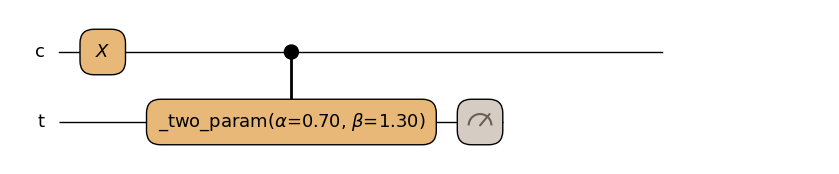

In [7]:
@qmc.qkernel
def _two_param(q: qmc.Qubit, alpha: qmc.Float, beta: qmc.Float) -> qmc.Qubit:
    q = qmc.rx(q, alpha)
    q = qmc.rz(q, beta)
    return q


@qmc.qkernel
def kwargs_in_order() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_two_param)
    c, t = cg(c, t, alpha=0.7, beta=1.3)
    return qmc.measure(t)


@qmc.qkernel
def kwargs_reversed() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_two_param)
    c, t = cg(c, t, beta=1.3, alpha=0.7)
    return qmc.measure(t)


exe_a = transpiler.transpile(kwargs_in_order)
exe_b = transpiler.transpile(kwargs_reversed)
assert str(exe_a.compiled_quantum[0].circuit) == str(exe_b.compiled_quantum[0].circuit)

kwargs_in_order.draw()

### 3.5 Controlling `U^k` with `power=`

Passing `power=k` controls the *k-th power* of the wrapped
unitary instead of `U` itself — the standard pattern in QPE,
where the j-th register applies a controlled-`U^(2**j)`.
`power` accepts a Python `int` (resolved at compile time) **or**
a `qmc.UInt` handle (resolved at transpile time from
`bindings`), and this works regardless of whether `num_controls`
is concrete or symbolic. Both shapes are shown side by side.

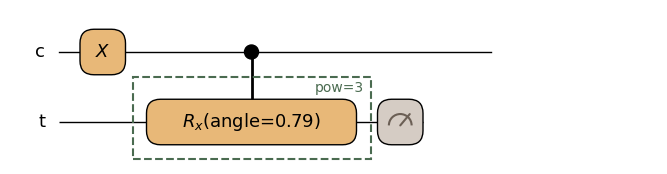

In [8]:
@qmc.qkernel
def power_demo_concrete() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(qmc.rx)  # num_controls = 1 (concrete)
    c, t = cg(c, t, angle=math.pi / 4, power=3)  # power is a Python int
    return qmc.measure(t)


@qmc.qkernel
def power_demo_symbolic(k: qmc.UInt) -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(qmc.rx)
    c, t = cg(c, t, angle=math.pi / 4, power=k)  # power is a UInt handle
    return qmc.measure(t)


power_demo_concrete.draw()

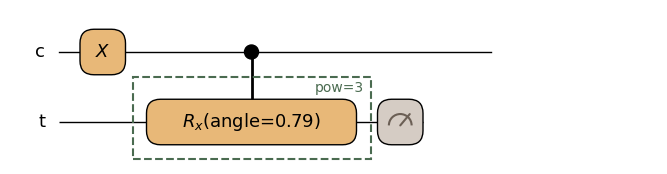

In [9]:
# Symbolic-power example needs a binding for `k` before draw / transpile.
power_demo_symbolic.draw(k=3)

## 4. Concrete-mode-only patterns

The shapes in this section require a Python-`int` value for
`num_controls`. They have no symbolic counterpart because
symbolic mode takes exactly **one** `Vector[Qubit]` argument as
its control pool — neither the multi-positional CCX form nor
the scalar / `VectorView` mixed prefix below is expressible
that way.

### 4.1 Multiple separate positional control args (CCX style)

With `num_controls=2`, the call site lists each control qubit
as its own positional argument before the target. The example
below is the canonical CCX (Toffoli): two controls `c0`, `c1`
and a target `t`. The same pattern extends to `num_controls=3`
(CCCX), `num_controls=4`, etc., as long as you have that many
distinct `Qubit` handles to pass in.

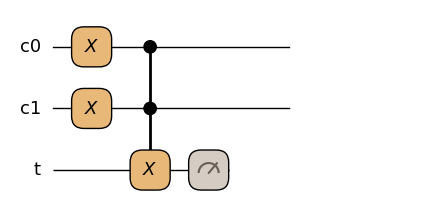

In [10]:
@qmc.qkernel
def toffoli_demo() -> qmc.Bit:
    c0 = qmc.qubit(name="c0")
    c1 = qmc.qubit(name="c1")
    t = qmc.qubit(name="t")
    c0 = qmc.x(c0)
    c1 = qmc.x(c1)
    ccx = qmc.control(qmc.x, num_controls=2)
    c0, c1, t = ccx(c0, c1, t)
    return qmc.measure(t)


toffoli_demo.draw()

### 4.2 Mixing scalar Qubit and `VectorView` controls

The positional control prefix in concrete mode may freely mix
scalar `Qubit` handles, `VectorView` slices, and whole
`Vector[Qubit]`s, as long as the total qubit count adds up to
`num_controls`. Here the three controls for a `num_controls=3`
controlled-H come from `qs[0]` (a scalar `Qubit`, 1 qubit) plus
`qs[1:3]` (a `VectorView`, 2 qubits). The same freedom does
not exist in symbolic mode, which takes exactly one control
argument.

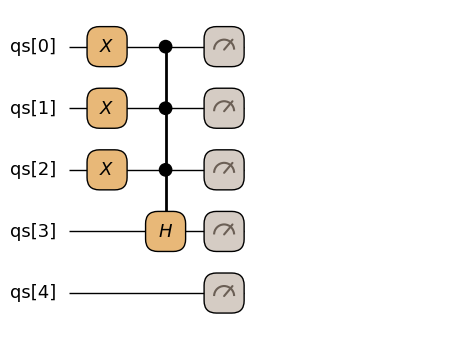

In [11]:
@qmc.qkernel
def mixed_controls_demo() -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(5, "qs")
    qs[0] = qmc.x(qs[0])
    qs[1] = qmc.x(qs[1])
    qs[2] = qmc.x(qs[2])
    cg = qmc.control(qmc.h, num_controls=3)
    qs[0], qs[1:3], qs[3] = cg(qs[0], qs[1:3], qs[3])
    return qmc.measure(qs)


mixed_controls_demo.draw()

## 5. Symbolic-mode-only patterns

These shapes require `num_controls` to be a `qmc.UInt` handle
(or any `UInt` expression like `n - 1`). They share two
defining properties:

- The control argument at the call site is a single pool — a
  `Vector[Qubit]` or `VectorView` — not several positional
  `Qubit` arguments.
- The number of *active* controls is decided at transpile time
  from `bindings`, not at decoration time.

A `controlled_indices=` keyword is available in symbolic mode
only; it picks which slots of the pool actually wire in as
active controls (the rest pass through untouched).

### 5.1 `num_controls = n` over a whole pool

The simplest symbolic shape: `num_controls=n` with the entire
pool (length `n`) used as the active controls. The kernel
parameter `n` is concretised at transpile time via `bindings`,
so the same `@qmc.qkernel` source supports any pool size.

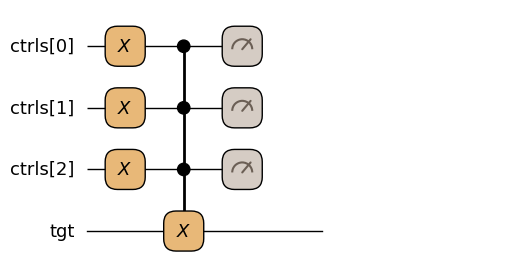

In [12]:
@qmc.qkernel
def symbolic_pool(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    ctrls = qmc.qubit_array(n, "ctrls")
    tgt = qmc.qubit(name="tgt")
    ctrls[0] = qmc.x(ctrls[0])
    ctrls[1] = qmc.x(ctrls[1])
    ctrls[2] = qmc.x(ctrls[2])
    cg = qmc.control(qmc.x, num_controls=n)
    ctrls, tgt = cg(ctrls, tgt)
    return qmc.measure(ctrls)


symbolic_pool.draw(n=3)

### 5.2 Canonical `n - 1` multi-controlled form

A frequent shape in multi-controlled-X designs: the first
`n - 1` qubits of a register become controls, the last one
becomes the target. The bound on `num_controls` is the
symbolic expression `n - 1`, and the control argument is the
slice `qs[0:n - 1]`.

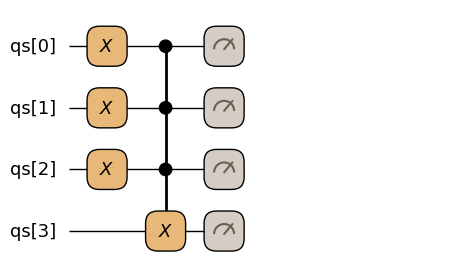

In [13]:
@qmc.qkernel
def mcx_demo(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(n, "qs")
    qs[0] = qmc.x(qs[0])
    qs[1] = qmc.x(qs[1])
    qs[2] = qmc.x(qs[2])
    mcx = qmc.control(qmc.x, num_controls=n - 1)
    qs[0 : n - 1], qs[n - 1] = mcx(qs[0 : n - 1], qs[n - 1])
    return qmc.measure(qs)


mcx_demo.draw(n=4)

### 5.3 Selecting a subset with `controlled_indices=`

When the control pool is wider than the number of active
controls you want, the `controlled_indices=` keyword (symbolic
mode only) picks exactly which pool slots are wired in. The
remaining slots are passed through untouched — they sit on the
wires but emit no extra gate of their own. The indices do not
have to be contiguous.

In the example below the pool has 4 qubits but the three
active controls are `pool[0]`, `pool[1]`, `pool[3]`
(`controlled_indices=[0, 1, 3]`). `pool[2]` is along for the
ride: no control dot is drawn on it, and the vertical
connection line of the MCX skips over it.

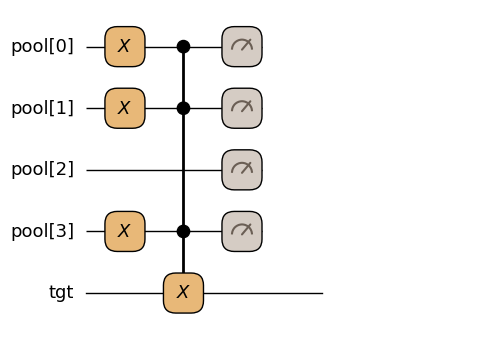

In [14]:
@qmc.qkernel
def subset_pool(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    pool = qmc.qubit_array(n, "pool")
    tgt = qmc.qubit(name="tgt")
    pool[0] = qmc.x(pool[0])
    pool[1] = qmc.x(pool[1])
    pool[3] = qmc.x(pool[3])  # pool[2] left at |0> — it is the inactive slot
    cg = qmc.control(qmc.x, num_controls=k_ctrls)
    pool, tgt = cg(pool, tgt, controlled_indices=[0, 1, 3])
    return qmc.measure(pool)


subset_pool.draw(n=4, k_ctrls=3)

### 5.4 `controlled_indices` with `UInt` entries

Each entry inside `controlled_indices` may be a Python `int`
literal, a `qmc.UInt` handle, or any arithmetic expression
over `UInt` values. Literal-`int` entries are validated at
compose time; entries that involve `UInt` handles are validated
at transpile time once `bindings` make them concrete.

Here the third active control is `pool[n - 1]` — "the last
pool slot" expressed as `UInt` arithmetic. At `n = 4` it still
resolves to slot 3, which leaves `pool[2]` inactive; the
compiled circuit is the same as in 5.3 and only the way the
index is spelled differs.

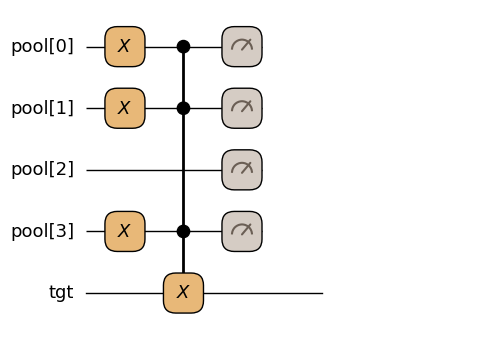

In [15]:
@qmc.qkernel
def subset_pool_with_uint(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    pool = qmc.qubit_array(n, "pool")
    tgt = qmc.qubit(name="tgt")
    pool[0] = qmc.x(pool[0])
    pool[1] = qmc.x(pool[1])
    pool[3] = qmc.x(pool[3])
    cg = qmc.control(qmc.x, num_controls=k_ctrls)
    pool, tgt = cg(pool, tgt, controlled_indices=[0, 1, n - 1])
    return qmc.measure(pool)


subset_pool_with_uint.draw(n=4, k_ctrls=3)

## 6. Patterns that don't work

Each cell below tries one rejected call shape and asserts the
expected exception type with a small `expect_error` helper.
The helper only catches the *expected* exception class; any
other exception propagates as a normal cell error so a
regression that changes which exception fires surfaces with a
traceback in the notebook. Missing the exception entirely
raises an `AssertionError`. The "Mode" column tells you which
mode of `qmc.control` each rejection applies to.

| Case | Mode | Exception |
| --- | --- | --- |
| 6.1 control qubit count mismatch | concrete | `ValueError` |
| 6.2 `controlled_indices=` in concrete mode | concrete | `ValueError` |
| 6.3 same qubit used twice | both | `QubitConsumedError` |
| 6.4 symbolic-length `VectorView` in concrete | concrete | `NotImplementedError` |
| 6.5 typo in classical kwarg | both | `TypeError` |
| 6.6 `bool` / negative / duplicate in `controlled_indices` | symbolic | `TypeError` / `ValueError` |
| 6.7 invalid `power` (zero or `bool`) | both | `ValueError` / `TypeError` |
| 6.8 `num_controls=0` | both | `ValueError` |
| 6.9 plain function with a Python default | both | `TypeError` |
| 6.10 same-pool slot reused as target | symbolic | `UnreturnedBorrowError` |

In [16]:
def expect_error(label: str, exc_type: type, body) -> None:
    """Assert that ``body`` raises an exception of ``exc_type``.

    The helper only catches the *expected* exception class.  Any
    other exception propagates out untouched so a regression that
    swaps the exception type surfaces with a normal traceback in
    the cell.  Missing the exception entirely raises an
    ``AssertionError``.
    """
    try:
        body()
    except exc_type as exc:
        print(f"[{type(exc).__name__}] {label}: {exc}")
        return
    raise AssertionError(
        f"{label}: expected {exc_type.__name__}, but no exception was raised"
    )

### 6.1 Control qubit count does not match `num_controls` (concrete)

Concrete mode counts positional control qubits at compose time.
Passing a slice that is too wide (or too narrow) for the
declared `num_controls` raises `ValueError`.

In [17]:
def case_count_mismatch() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        qs = qmc.qubit_array(6, "qs")
        cg = qmc.control(qmc.x, num_controls=3)
        view, t = cg(qs[0:5], qs[5])  # 5 qubits supplied, 3 expected
        qs[0:5] = view
        return qmc.measure(qs[5])

    _ = kernel.block


expect_error("control count mismatch", ValueError, case_count_mismatch)

[ValueError] control count mismatch: concrete num_controls=3: positional argument #0 would push the control qubit count from 0 to 5, crossing the control / sub-kernel boundary mid-argument.  Split the argument so the boundary falls between args.


### 6.2 `controlled_indices=` in concrete mode (concrete)

`controlled_indices` makes sense only when there is a control
*pool* to select from, which is a symbolic-mode concept.
Supplying it alongside a concrete `num_controls` raises
`ValueError` at compose time.

In [18]:
def case_controlled_indices_in_concrete() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.x)  # num_controls defaults to 1 (concrete)
        c, t = cg(c, t, controlled_indices=[0])
        return qmc.measure(t)

    _ = kernel.block


expect_error(
    "controlled_indices in concrete mode",
    ValueError,
    case_controlled_indices_in_concrete,
)

[ValueError] controlled_indices in concrete mode: controlled_indices is only valid in symbolic mode (num_controls=UInt).  Got concrete num_controls; concrete-mode controls are positional and have no selection step (see design §1.1).


### 6.3 Using the same qubit twice (both modes)

Each `Qubit` handle can be consumed once. Passing the same
scalar `Qubit` to both a control and the target — or to two
control positions — is caught by the linear-type machinery as a
`QubitConsumedError`. The same restriction applies in symbolic
mode if the pool argument and another argument share a slot.

In [19]:
def case_alias() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        q = qmc.qubit(name="q")
        cg = qmc.control(qmc.x)
        a, b = cg(q, q)  # control and target both reference q
        return qmc.measure(b)

    _ = kernel.block


expect_error("alias (q used twice)", QubitConsumedError, case_alias)

[QubitConsumedError] alias (q used twice): Qubit 'qubit_9477674e' was already consumed by 'ControlledU[control]' and cannot be used again in 'ControlledU[target]'.

Affine type rule: Each qubit handle can only be used once. After a gate operation, reassign the result to use the new handle.

Fix:
  q = qm.h(q)  # Reassign to capture the new handle
  q = qm.x(q)  # Use the reassigned handle


### 6.4 Symbolic-length `VectorView` in concrete mode (concrete)

Concrete mode must compute the qubit count of every control
argument at compile time. A slice whose length depends on a
`UInt` (here `qs[0:m]` for symbolic `m`) is not yet supported
in concrete mode and raises `NotImplementedError`. The
workaround is to switch to symbolic mode — `num_controls=m`
with `cg(qs, t)` accepts exactly this shape (see Section 5.1).

In [20]:
def case_symbolic_view_in_concrete() -> None:
    @qmc.qkernel
    def kernel(m: qmc.UInt) -> qmc.Bit:
        qs = qmc.qubit_array(m, "qs")
        cg = qmc.control(qmc.x, num_controls=3)
        view, q_out = cg(qs[0:m], qs[m - 1])
        qs[0:m] = view
        qs[m - 1] = q_out
        return qmc.measure(qs[m - 1])

    _ = kernel.block


expect_error(
    "symbolic-length VectorView in concrete mode",
    NotImplementedError,
    case_symbolic_view_in_concrete,
)

[NotImplementedError] symbolic-length VectorView in concrete mode: concrete num_controls with a symbolic-length Vector / VectorView control is not yet implemented in the frontend (tracked under Step 2.b of the controlled-API redesign).


### 6.5 Typo in a classical keyword argument (both modes)

`qmc.control` inspects the wrapped kernel's signature, so an
unknown keyword name is caught at compose time. The error
message lists the parameters the wrapper actually understands.

In [21]:
def case_kwarg_typo() -> None:
    @qmc.qkernel
    def _gate(q: qmc.Qubit, angle: qmc.Float) -> qmc.Qubit:
        return qmc.rx(q, angle)

    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(_gate)
        c, t = cg(c, t, agnle=0.5)  # typo: agnle -> angle
        return qmc.measure(t)

    _ = kernel.block


expect_error("classical kwarg typo", TypeError, case_kwarg_typo)

[TypeError] classical kwarg typo: control(): unknown parameter(s) ['agnle']. The wrapped kernel's classical parameters are ['angle'].


### 6.6 Invalid entries in `controlled_indices` (symbolic)

`controlled_indices` is symbolic-mode-only (see 6.2), and its
literal entries are validated at compose time:

- `bool` values (`True` / `False`) are rejected even though
  Python treats them as ints, to prevent the silent
  ``True == 1`` / ``False == 0`` confusion. Cast explicitly
  to `int(...)` if you really mean that.
- Negative literals are rejected — pool indices are unsigned.
- Duplicate literals are rejected because each pool slot wires
  in at most one active control.

In [22]:
def case_bool_entry() -> None:
    @qmc.qkernel
    def kernel(k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        pool = qmc.qubit_array(3, "pool")
        tgt = qmc.qubit(name="tgt")
        cg = qmc.control(qmc.z, num_controls=k_ctrls)
        pool, tgt = cg(pool, tgt, controlled_indices=[True, 1])
        return qmc.measure(pool)

    _ = kernel.block


def case_negative_entry() -> None:
    @qmc.qkernel
    def kernel(k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        pool = qmc.qubit_array(3, "pool")
        tgt = qmc.qubit(name="tgt")
        cg = qmc.control(qmc.z, num_controls=k_ctrls)
        pool, tgt = cg(pool, tgt, controlled_indices=[-1, 0, 1])
        return qmc.measure(pool)

    _ = kernel.block


def case_duplicate_entry() -> None:
    @qmc.qkernel
    def kernel(k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        pool = qmc.qubit_array(3, "pool")
        tgt = qmc.qubit(name="tgt")
        cg = qmc.control(qmc.z, num_controls=k_ctrls)
        pool, tgt = cg(pool, tgt, controlled_indices=[0, 0, 1])
        return qmc.measure(pool)

    _ = kernel.block


expect_error("controlled_indices: bool entry", TypeError, case_bool_entry)
expect_error("controlled_indices: negative entry", ValueError, case_negative_entry)
expect_error("controlled_indices: duplicate entry", ValueError, case_duplicate_entry)

[TypeError] controlled_indices: bool entry: controlled_indices: bool entry (True) is not allowed; cast to int explicitly if intentional.
[ValueError] controlled_indices: negative entry: controlled_indices: negative entry (-1) is not allowed.
[ValueError] controlled_indices: duplicate entry: controlled_indices: duplicate int entry (0).


### 6.7 Invalid `power` (both modes)

`power` must be a strictly positive integer (`int` or
`qmc.UInt`). Zero and negative values raise `ValueError`. A
Python `bool` is rejected as `TypeError` so that `power=True`
does not silently mean `power=1`. The same restriction applies
in both concrete and symbolic mode.

In [23]:
def case_power_zero() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.x)
        c, t = cg(c, t, power=0)
        return qmc.measure(t)

    _ = kernel.block


def case_power_bool() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.x)
        c, t = cg(c, t, power=True)
        return qmc.measure(t)

    _ = kernel.block


expect_error("power=0", ValueError, case_power_zero)
expect_error("power=True (bool)", TypeError, case_power_bool)

[ValueError] power=0: power must be a strictly positive integer, got 0.
[TypeError] power=True (bool): power must be a positive integer, got bool (True). Use an integer value like power=1 or power=2.


### 6.8 `num_controls=0` (both modes)

A controlled gate with zero controls would just be the
underlying gate, which makes the wrapper meaningless.
`qmc.control` rejects this at decoration time as `ValueError`.
Negative `num_controls` is rejected the same way.

In [24]:
def case_num_controls_zero() -> None:
    qmc.control(qmc.x, num_controls=0)


expect_error("num_controls=0", ValueError, case_num_controls_zero)

[ValueError] num_controls=0: num_controls must be >= 1, got 0.


### 6.9 Plain function with a Python default (both modes)

When the callable passed to `qmc.control` is not a `@qmc.qkernel`
(just a plain Python function), the wrapper auto-synthesises a
kernel around it. The synthesiser cannot turn Python-side
default values into IR-level defaults, so plain functions with
defaults are rejected at decoration time. The fix is to mark
the function as a `@qmc.qkernel` (where defaults are tracked
end-to-end) or to drop the default and pass the value
explicitly at the call site.

In [25]:
def case_plain_fn_with_default() -> None:
    def _bad_sub(q: qmc.Qubit, theta: qmc.Float = 0.5) -> qmc.Qubit:
        return qmc.rx(q, theta)

    qmc.control(_bad_sub)


expect_error("plain function with default value", TypeError, case_plain_fn_with_default)

[TypeError] plain function with default value: control(): parameter 'theta' of '_bad_sub' has a default value (0.5), which the wrapper synthesizer does not propagate. Wrap the function in @qmc.qkernel manually.


### 6.10 Same-pool slot reused as target (symbolic)

In symbolic mode the control argument is the *whole* pool, and
inactive slots (those not in `controlled_indices`) sit on the
diagram as pass-through wires. It is tempting to reach into the
same pool and pass one of those inactive slots as the target —
e.g. `cg(pool, pool[2], controlled_indices=[0, 1, 3])` so that
`pool[2]` becomes the target of the controlled-U. The call site
is rejected by the linear-type borrow tracker because the pool
is already being consumed as one argument while `pool[2]` is
being borrowed for another, which surfaces as
`UnreturnedBorrowError` at compose time.

Workaround: switch to concrete mode and pass each slot
individually (see Section 4.2). With concrete mode the four
`pool[i]` slots are independent `Qubit` arguments — three as
controls, one as target — and the borrow tracker is satisfied.

In [26]:
def case_pool_slot_as_target() -> None:
    @qmc.qkernel
    def kernel(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        pool = qmc.qubit_array(n, "pool")
        cg = qmc.control(qmc.x, num_controls=k_ctrls)
        pool, q = cg(pool, pool[2], controlled_indices=[0, 1, 3])
        pool[2] = q
        return qmc.measure(pool)

    _ = kernel.block


expect_error(
    "same-pool slot reused as target",
    UnreturnedBorrowError,
    case_pool_slot_as_target,
)

[UnreturnedBorrowError] same-pool slot reused as target: Array 'pool' has unreturned borrowed elements.
Borrowed elements: pool[2]

Fix: Write back all borrowed elements before using the array:
  q = pool[i]
  q = qm.h(q)
  pool[i] = q  # Return the element


## 7. Summary

*(to be written)*